In [18]:
# !pip install pandas numpy scikit-learn tensorflow matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [19]:
df = pd.read_csv("dataset/cropdata_updated.csv")
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [21]:
# Rename columns if needed
df.columns = [col.lower() for col in df.columns]

# Example mapping (adjust based on dataset)
df = df.rename(columns={
    "temperature": "temp",
    "humidity": "humidity",
    "result": "irrigation"
})

# Ensure irrigation column has only 0 and 1
df["irrigation"] = df["irrigation"].astype(int)
df["irrigation"] = (df["irrigation"] > 0).astype(int)  # Convert to binary if needed

# Add crop column (simulate)
crop_map = {"rice":0, "wheat":1, "maize":2, "vegetables":3, "pulses":4}
df["crop"] = np.random.randint(0,5,len(df))

# Generate synthetic raw soil (0–1023)
df["soil_raw"] = (
    1023 * (1 - (
        0.5 * (df["humidity"] / 100) +
        0.3 * (1 / (df["temp"] + 1))
    ))
)

# Add noise
df["soil_raw"] += np.random.randint(-50, 50, len(df))

# Clip values to sensor range
df["soil_raw"] = df["soil_raw"].clip(0, 1023)

df["soil"] = 1 - (df["soil_raw"] / 1023)

X = df[["temp","humidity","crop","soil"]]
y = df["irrigation"]

print(f"Unique values in irrigation column: {df['irrigation'].unique()}")

Unique values in irrigation column: [1 0]


In [22]:
print(X.head())

   temp  humidity  crop      soil
0    25      80.0     1  0.394921
1    26      77.0     2  0.397089
2    27      74.0     0  0.425680
3    28      71.0     0  0.336997
4    29      68.0     3  0.365640


In [23]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [24]:
from tensorflow.keras.layers import Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L2

# Improved model architecture with BatchNormalization and L2 regularization
model = Sequential([
    Input(shape=(4,)),
    Dense(64, activation='relu', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    
    Dense(16, activation='relu', kernel_regularizer=L2(0.001)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(8, activation='relu', kernel_regularizer=L2(0.001)),
    Dropout(0.1),
    
    Dense(1, activation='sigmoid')
])

# Use custom learning rate for better convergence
optimizer = Adam(learning_rate=0.0005)  # Reduced learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,297 (12.88 KB)

 Non-trainable params: 224 (896.00 B)

None


In [25]:
# Early stopping and learning rate reduction
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print(f"Class weights: {class_weight_dict}")

history = model.fit(
    X_train, y_train,
    epochs=300,  # Increased epochs
    batch_size=8,  # Smaller batch size for better convergence
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,  # Handle class imbalance
    verbose=1
)

Class weights: {0: np.float64(0.9055042074768934), 1: np.float64(1.116516414356183)}
Epoch 1/300
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7334 - loss: 0.5984 - val_accuracy: 0.8325 - val_loss: 0.4775 - learning_rate: 5.0000e-04
Epoch 2/300
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7575 - loss: 0.5531 - val_accuracy: 0.8203 - val_loss: 0.4635 - learning_rate: 5.0000e-04
Epoch 3/300
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7697 - loss: 0.5249 - val_accuracy: 0.8410 - val_loss: 0.4347 - learning_rate: 5.0000e-04
Epoch 4/300
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7784 - loss: 0.5040 - val_accuracy: 0.8410 - val_loss: 0.4238 - learning_rate: 5.0000e-04
Epoch 5/300
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7825 - loss: 0.4833 - val_accuracy: 0.8407 - val_loss: 0.4106 - learning_rate: 5.0000e-04
Epoch 6/300
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7869 - loss: 0.4703 - val_accuracy: 0.8051 - val_lo

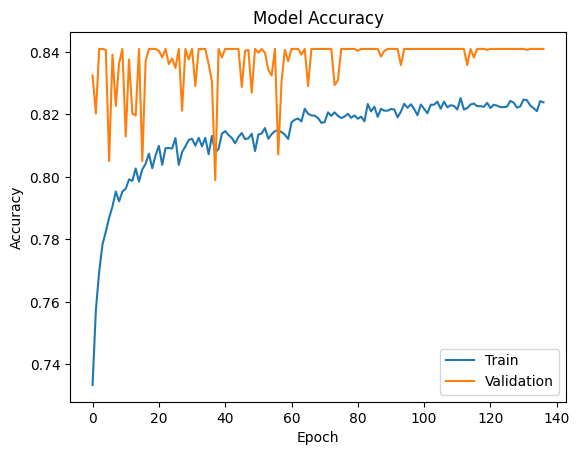

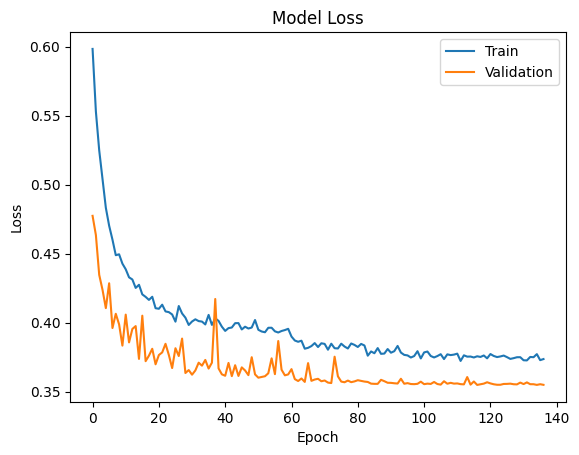

In [26]:
# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [27]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("Final Accuracy:", acc)

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Final Accuracy: 0.8409990862016449



DETAILED MODEL EVALUATION

Confusion Matrix:
[[1291  522]
 [   0 1470]]

Classification Report:
                   precision    recall  f1-score   support

    No Irrigation       1.00      0.71      0.83      1813
Irrigation Needed       0.74      1.00      0.85      1470

         accuracy                           0.84      3283
        macro avg       0.87      0.86      0.84      3283
     weighted avg       0.88      0.84      0.84      3283



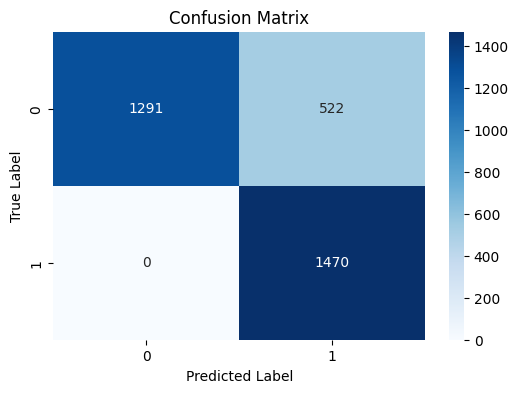

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Detailed metrics
print("\n" + "="*50)
print("DETAILED MODEL EVALUATION")
print("="*50)
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['No Irrigation', 'Irrigation Needed']))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [28]:
print("\n" + "="*60)
print("DIAGNOSIS: CHECKING FOR LABEL ISSUES")
print("="*60)
print(f"\nUnique values in y_test: {np.unique(y_test)}")
print(f"Unique values in y_pred: {np.unique(y_pred)}")
print(f"y_test value counts:\n{pd.Series(y_test).value_counts()}")
print(f"y_pred value counts:\n{pd.Series(y_pred.flatten()).value_counts()}")


DIAGNOSIS: CHECKING FOR LABEL ISSUES

Unique values in y_test: [0 1]
Unique values in y_pred: [0 1]
y_test value counts:
irrigation
0    1813
1    1470
Name: count, dtype: int64
y_pred value counts:
1    1992
0    1291
Name: count, dtype: int64


In [ ]:
sample = np.array([[30, 60, 0.5, 0]])  # temp, humidity, soil, crop
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
print("Irrigation Needed:", int(prediction[0][0] > 0.5))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Irrigation Needed: 1


d:\cropthingy\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [33]:
# Save model in modern .keras format (replaces deprecated .h5)
model.save("irrigation_model.keras")
print("✓ Model saved as irrigation_model.keras")

import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved as scaler.pkl")

✓ Model saved as irrigation_model.keras
✓ Scaler saved as scaler.pkl
